<h3 style="text-align: center;">SVM - Decision Tree</h3>

<h3>Project Description</h3>

<h9>The goal of this project is to accurately classify Diet for a person using a dateset of diet recommendation. The dataset comprises a sequence of 10 features representing the biometric numbers of a person.</h9>

<h4>Problem Statement</h4>

Recommend a correct diet is critical task for a person. So here we are trying to recommend a correct diet for a person using the dataset of diet recommendation. Despite the availability of advanced machine learning techniques, achieving high accuracy in diet recommendation remains challenging due to variations in age, bmi, and cholesterol.

This project aims to address this challenge by developing and evaluating three machine learning models—Support Vector Machine (SVM) and Decision Tree—to classify diet based on biometric numbers of a person. The goal is to determine which model performs best in terms of accuracy, precision, recall, and F1-score, thereby providing a robust solution for diet recommendation tasks.

The outcomes of this study will contribute to the understanding of model performance on various type of diets.

<h4>Objectives</h4>

<ul>
<li><h5>Data Preprocessing:</h5> Clean and prepare the data for model training.</li>
<li><h5>Model Development: </h5>Implement Support Vector Machine (SVM) and Decision Tree classifiers.</li>
<li><h5>Model Training and Evaluation: </h5>Train the models on the training set and evaluate their performance using metrics such as accuracy, precision, recall, and F1-score.</li>
<li><h5>Model Comparison: </h5>Compare the models to identify the best performer in terms of classification accuracy and generalization.</li>
<li><h5>Conclusion: </h5>Summarize the findings and provide recommendations for potential improvements.</li>
</ul>

<h4>About the Dataset</h4>

The dataset consists of samples of biometric of a person, where each sample is represented by a set of 9 features derived from the survey. These features capture various aspects of the information about the biometric.
<ul>
    <li><h5>Dataset: </h5><h6>Diet Recommendation Dataset</h6></li>
    <li><h5>Content: </h5><h6>Data on various features extracted from survey.</h6></li>
    <li><h5>Number of Rows: </h5><h6>1000</h6></li>
    <li><h5>Number of Columns: </h5><h6>10 (9 input features + 1 class label)</h6></li>
</ul>

<h3>EXPLORATORY DATA ANALYSIS (EDA)</h3>

<h4>Import the Libraries</h4>

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score,f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


<h4>Read the Dataset</h4>

In [2]:
df0 = pd.read_csv('diet_recommendation_dataset_1000.csv')
df = df0.copy()

In [3]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1000 non-null   int64  
 1   Gender          1000 non-null   int64  
 2   Height_cm       1000 non-null   int64  
 3   Weight_kg       1000 non-null   int64  
 4   BMI             1000 non-null   float64
 5   Activity_Level  1000 non-null   int64  
 6   Sugar_Level     1000 non-null   int64  
 7   Cholesterol     1000 non-null   int64  
 8   Goal            1000 non-null   int64  
 9   Diet            1000 non-null   object 
dtypes: float64(1), int64(8), object(1)
memory usage: 78.3+ KB


<h4>Rename the Columns</h4>

In [5]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet'],
      dtype='object')

In [3]:
df.rename(columns={
    'Age':'age',
    'Gender':'gender',
    'Height_cm':'height_cm',
    'Weight_kg':'weight_kg',
    'BMI':'BMI',
    'Activity_Level':'activity_level',
    'Sugar_Level':'sugar_level',
    'Cholesterol':'cholesterol',
    'Goal':'goal',
    'Diet':'diet'
},inplace=True)

In [7]:
df.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'BMI', 'activity_level',
       'sugar_level', 'cholesterol', 'goal', 'diet'],
      dtype='object')

<h4>Check Missing Values</h4>

In [8]:
# Check out the missing values

missing_count = df.isnull().sum()
value_count = df.isnull().count()
missing_percentage = round(missing_count / value_count * 100, 2)
missing_df = pd.DataFrame({"count": missing_count, "percentage": missing_percentage})
missing_df

,count,percentage
age,0,0.0
gender,0,0.0
height_cm,0,0.0
weight_kg,0,0.0
BMI,0,0.0
activity_level,0,0.0
sugar_level,0,0.0
cholesterol,0,0.0
goal,0,0.0
diet,0,0.0


<h4>Check Duplicated Values</h4>

In [9]:
# Checks duplicates and drops them

def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep='first').sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep='first', inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

duplicate_values(df)

Duplicate check...
There are no duplicated observations in the dataset.


<h4>Distributions</h4>

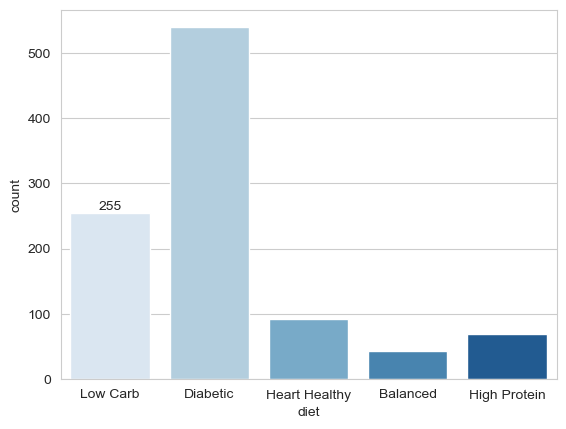

In [10]:
# Targer Feature "diet"

ax = sns.countplot( data=df, x="diet", palette='Blues')
ax.bar_label(ax.containers[0])
plt.show()

<strong>Conclusion :-</strong> dataset is <strong>Imbalanced.</strong>

In this dataset :
<ul>
<li>Majority of <strong>diet</strong> is first <strong>Diabetic</strong> and second <strong>Low Carb</strong>.</li>
<li>Minority of <strong>diet</strong> is first <strong>Balanced</strong>, second <strong>High Protein</strong> and third <strong>Heart Healthy</strong> diet.</li>
</ul>

In [ ]:
# Basic statistics summary of Numerical features

df.describe().T

In [12]:
# Basic statistics summary of Object features

df.describe(include= 'object').T

,count,unique,top,freq
diet,1000,5,Diabetic,539


<h3>Numerical Features</h3>

<h4>Distributions of Numerical Features</h4>

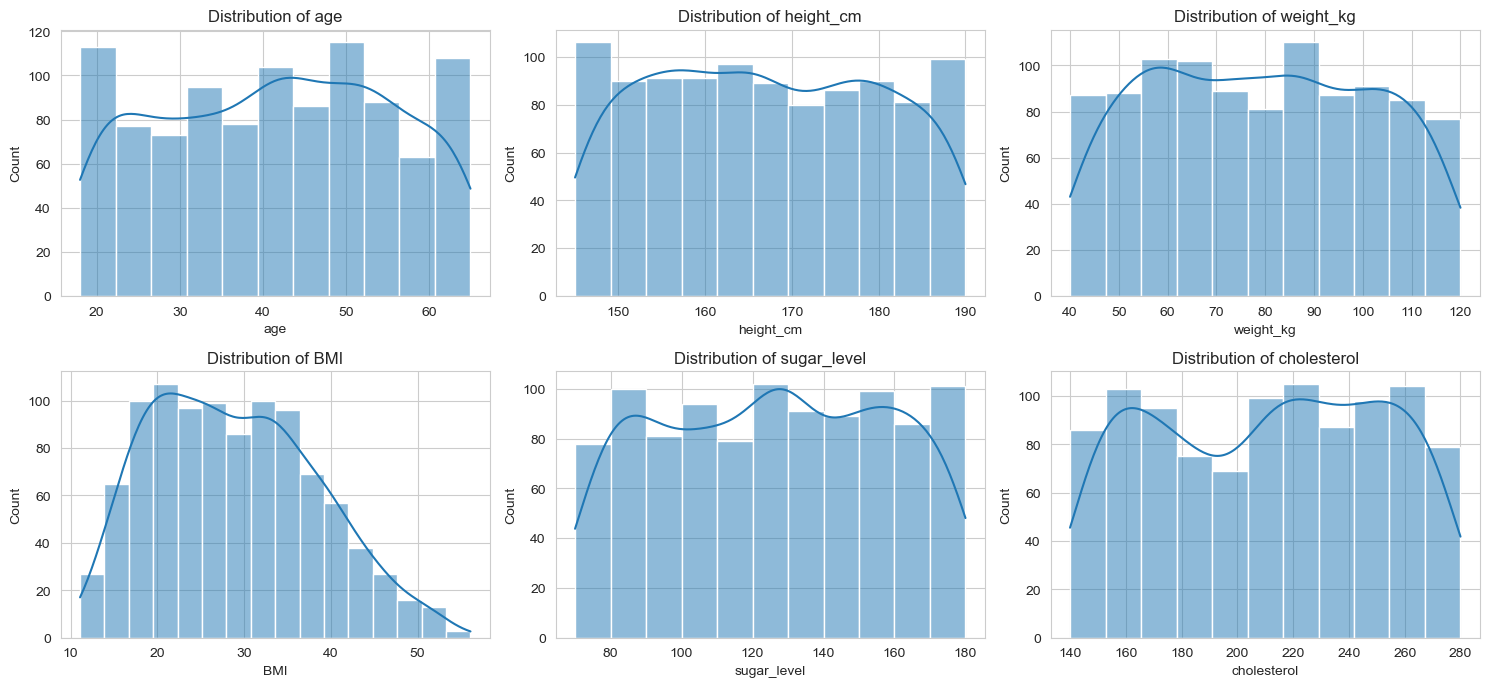

In [13]:
numerical_df = df[['age', 'height_cm', 'weight_kg', 'BMI','sugar_level', 'cholesterol']]

plt.figure(figsize=(15, 10))

num_vars = len(numerical_df.columns)

for i, var in enumerate(numerical_df.columns, 1):
    plt.subplot((num_vars // 3) + 1, 3, i)
    sns.histplot(data=df, x=var, kde=True)
    plt.title(f'Distribution of {var}')
    
plt.tight_layout()
plt.show()

<h3>Categorical Features</h3>

<h4>Distributions of Categorical Features</h4>

<Axes: xlabel='diet'>

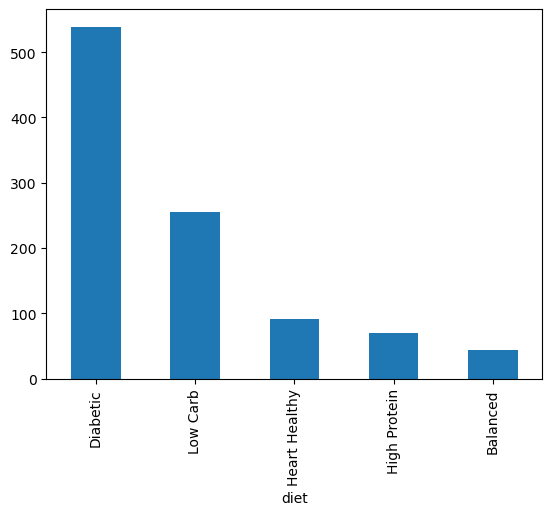

In [4]:
df['diet'].value_counts().plot(kind='bar')

<h4>Correlations</h4>

In [4]:
le=LabelEncoder()

In [5]:
df['diet']=le.fit_transform(df['diet'])

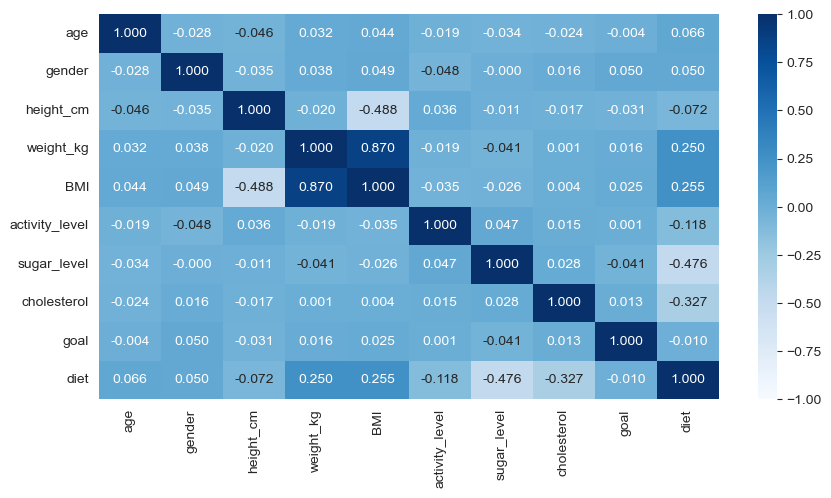

In [20]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), vmin = -1, vmax = 1, annot = True, fmt = '.3f', cmap='Blues');
plt.show()

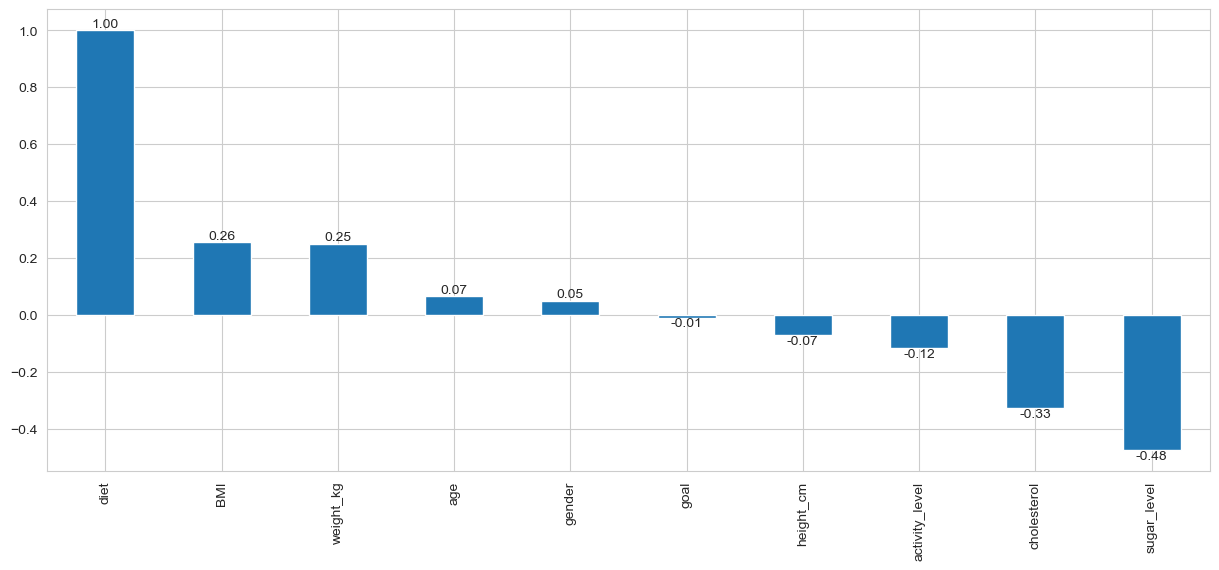

In [21]:
correlation_matrix = df.corr() # Labeled df
price_corr = correlation_matrix['diet'].sort_values(ascending= False)

ax =  price_corr.plot(kind='bar',figsize=(15,6))
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.show()

<h4>Analysis</h4>

For a <strong>diet</strong> column :
<ul>
<li><strong>BMI</strong> and <strong>Weight_kg</strong> correlation_score is <strong>positivly</strong> High.</li>
<li><strong>Cholesterol</strong> and <strong>Sugar_level</strong> correlation_score is <strong>negativly</strong> High.</li>
<li><strong>Goal</strong> column correlation_score is very low.</li>
</ul>

<h4>Outliers Analysis</h4>

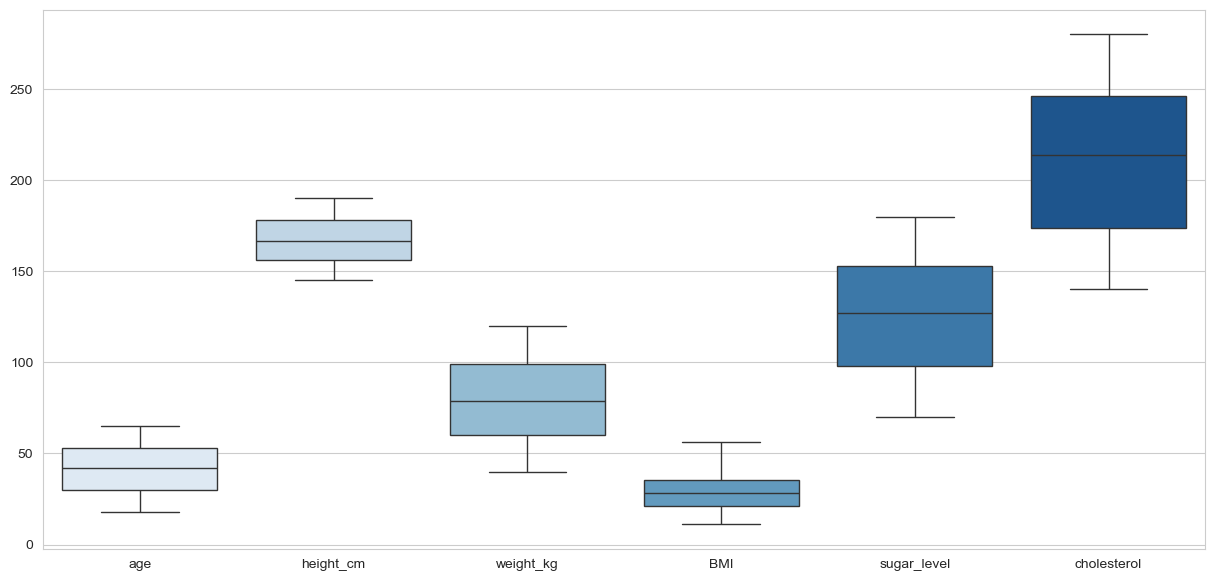

In [22]:
# Boxplot of all features by target 

plt.figure(figsize=(15,7))
sns.boxplot(data=df.drop(['gender','activity_level','diet','goal'], axis=1),palette='Blues');
plt.show()

<strong>Conclusion :-</strong> No outliers present.

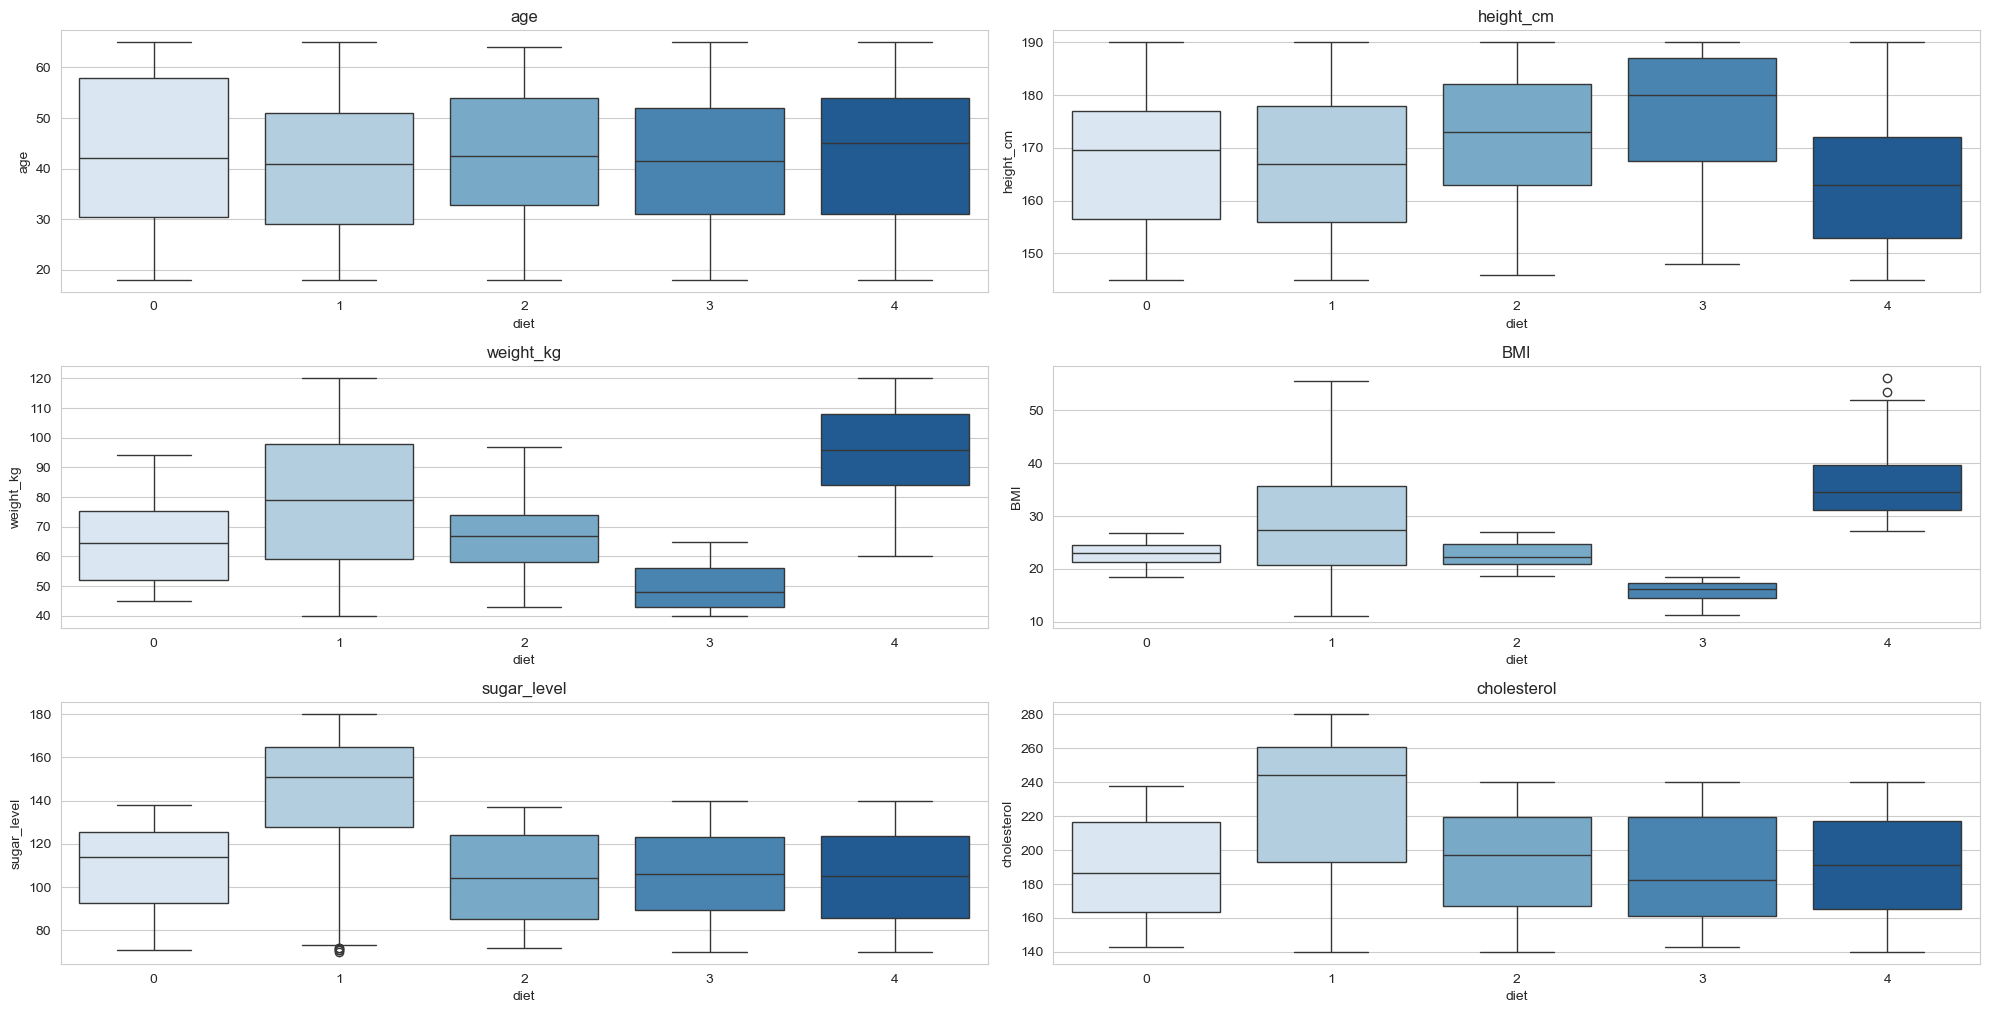

In [23]:
# 2) Boxplotting all Features with the values by target

numerical_df = df[['age', 'height_cm', 'weight_kg', 'BMI','sugar_level', 'cholesterol']]

plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_df, 1):
    plt.subplot(9, 2, i)
    plt.title(col)
    sns.boxplot(x='diet', y=col, data=df,palette='Blues')
plt.tight_layout()  
plt.show()


<h3>MACHINE LEARNING</h3>

<h4>Data Preprocessing</h4>

In [6]:
X = df.drop(columns=['diet'])
y = df['diet']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [8]:
# Scaler

scaler = StandardScaler()

In [9]:
# Function to Evaluate the Model Performans using Classification Confusion_matrix() 
# Also does the prediction in the function

def eval_metric(model, X_train, y_train, X_test, y_test, i):

    """ to get the metrics for the model """

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print(f"{i} Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print('--------------------------------------------------------')
    print(f"{i} Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

<h3>Support Vector Machine Classification (SVM)</h3>

In [11]:
# Set and scale
svm_model = Pipeline([("scaler", MinMaxScaler()), ("SVC", SVC(kernel="rbf", random_state=101))])

#Fit the model
svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('SVC', SVC(random_state=101))])

<h4>Evaluating the Model Performance</h4>

In [12]:
#Prediction
y_pred_test = svm_model.predict(X_test)
y_pred_train = svm_model.predict(X_train)

# Evaluating the Model Performance Scores
SVM_accuracy_test = accuracy_score(y_test, y_pred_test)
SVM_accuracy_train = accuracy_score(y_train, y_pred_train)

svm_f1_test = f1_score(y_test, y_pred_test, average='macro')
svm_f1_train = f1_score(y_train, y_pred_train, average='macro')

print('----------------------------------------------------')
print('SVM_accuracy_test:', SVM_accuracy_test)
print('SVM_accuracy_train:', SVM_accuracy_train)
print('svm_f1_test:', svm_f1_test)
print('svm_f1_train:', svm_f1_train)
print('----------------------------------------------------')

# Evaluating the Model Performance using Classification Metrics
eval_metric(svm_model, X_train, y_train, X_test, y_test, 'svm_model')


----------------------------------------------------
SVM_accuracy_test: 0.835
SVM_accuracy_train: 0.9225
svm_f1_test: 0.7359026884120772
svm_f1_train: 0.8899618567830154
----------------------------------------------------
svm_model Test_Set
[[  4   5   0   0   0]
 [  0 102   0   0   6]
 [  0   6  11   0   1]
 [  0   4   3   7   0]
 [  0   7   1   0  43]]
              precision    recall  f1-score   support

           0       1.00      0.44      0.62         9
           1       0.82      0.94      0.88       108
           2       0.73      0.61      0.67        18
           3       1.00      0.50      0.67        14
           4       0.86      0.84      0.85        51

    accuracy                           0.83       200
   macro avg       0.88      0.67      0.74       200
weighted avg       0.84      0.83      0.83       200


--------------------------------------------------------
svm_model Train_Set
[[ 27   5   0   0   3]
 [  0 423   0   2   6]
 [  0  12  62   0   0]
 [  1 

<h4>Model Validation</h4>

In [12]:
# Cross Validation Scores of the Model Performance

model =  Pipeline([("scaler", MinMaxScaler()), ("SVC", SVC(kernel="rbf", random_state=101))])

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"],
                        cv=5,
                        return_train_score=True)

df_scores = pd.DataFrame(scores, index=range(1, 6)) 
df_scores.mean()[2:]

test_accuracy            0.850000
train_accuracy           0.913125
test_precision_macro     0.838325
train_precision_macro    0.939361
test_recall_macro        0.680698
train_recall_macro       0.826236
test_f1_macro            0.728965
train_f1_macro           0.873563
dtype: float64

In [13]:
svm_model.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()), ('SVC', SVC(random_state=101))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'SVC': SVC(random_state=101),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'SVC__C': 1.0,
 'SVC__break_ties': False,
 'SVC__cache_size': 200,
 'SVC__class_weight': None,
 'SVC__coef0': 0.0,
 'SVC__decision_function_shape': 'ovr',
 'SVC__degree': 3,
 'SVC__gamma': 'scale',
 'SVC__kernel': 'rbf',
 'SVC__max_iter': -1,
 'SVC__probability': False,
 'SVC__random_state': 101,
 'SVC__shrinking': True,
 'SVC__tol': 0.001,
 'SVC__verbose': False}

<h4>Hyperparameter Optimization for SVM Model</h4>

In [13]:
# SVM Model Hyperparameters Tuning with GridSearchSV 

model = Pipeline([("scaler",MinMaxScaler()),("SVM", SVC(kernel="rbf", probability=True))]) 


param_grid = {'SVM__C':[ 1,10,15],
              'SVM__gamma':["scale", "auto"]
             }

svm_grid_model = GridSearchCV(model,
                          param_grid,
                          scoring = "accuracy",   
                          n_jobs = -1, # Uses all available cores
                          verbose=1,
                          return_train_score=True).fit(X_train, y_train) # fit the model

svm_grid_model

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('SVM', SVC(probability=True))]),
             n_jobs=-1,
             param_grid={'SVM__C': [1, 10, 15],
                         'SVM__gamma': ['scale', 'auto']},
             return_train_score=True, scoring='accuracy', verbose=1)

In [15]:
svm_grid_model.best_params_

{'SVM__C': 15, 'SVM__gamma': 'scale'}

<h4>Evaluating the Model Performance</h4>

In [14]:
#Prediction
y_pred_test = svm_grid_model.predict(X_test)
y_pred_train = svm_grid_model.predict(X_train)

# Evaluating the Model Performance Scores
svm_grid_accuracy_test = accuracy_score(y_test, y_pred_test)
svm_grid_accuracy_train = accuracy_score(y_train, y_pred_train)

svm_grid_f1_test = f1_score(y_test, y_pred_test, average='macro')
svm_grid_f1_train = f1_score(y_train, y_pred_train, average='macro')

print('svm_grid_accuracy_test:', svm_grid_accuracy_test)
print('svm_grid_accuracy_train:', svm_grid_accuracy_train)
print('svm_grid_f1_test:', svm_grid_f1_test)
print('svm_grid_f1_train:', svm_grid_f1_train)

print('---------------------------------------------')
# Evaluating the Model Performance using Classification Metrics
eval_metric(svm_grid_model, X_train, y_train, X_test, y_test, 'svm_grid_model')

svm_grid_accuracy_test: 0.855
svm_grid_accuracy_train: 0.995
svm_grid_f1_test: 0.7444488748936382
svm_grid_f1_train: 0.9971036307243203
---------------------------------------------
svm_grid_model Test_Set
[[  5   1   1   1   1]
 [  2 102   1   0   3]
 [  0   2  14   1   1]
 [  1   1   4   8   0]
 [  0   6   3   0  42]]
              precision    recall  f1-score   support

           0       0.62      0.56      0.59         9
           1       0.91      0.94      0.93       108
           2       0.61      0.78      0.68        18
           3       0.80      0.57      0.67        14
           4       0.89      0.82      0.86        51

    accuracy                           0.85       200
   macro avg       0.77      0.73      0.74       200
weighted avg       0.86      0.85      0.85       200


--------------------------------------------------------
svm_grid_model Train_Set
[[ 35   0   0   0   0]
 [  0 430   0   0   1]
 [  0   0  74   0   0]
 [  0   0   0  56   0]
 [  0   3   0 

<h4>Comparing the SVM Models</h4>
<ol>
<li><h5>SVM Grid Model:</h5></li>
 <ul>
 <li><h6>Test Accuracy: 0.855</h6></li>
 <li><h6>Train Accuracy: 0.995</h6></li>
 <li><h6>Test F1 Score: 0.744</h6></li>
 <li><h6>Train F1 Score: 0.997</h6></li>
 </ul>
<li><h5>SVM Model:</h5></li>
 <ul>
 <li><h6>Test Accuracy: 0.835</h6></li>
 <li><h6>Train Accuracy: 0.9225</h6></li>
 <li><h6>Test F1 Score: 0.736</h6></li>
 <li><h6>Train F1 Score: 0.89</h6></li>
 </ul>
</ol>

<h3>Decision Tree Classification (DTC)</h3>

In [10]:
# Set and scale
DT_model = DecisionTreeClassifier(random_state=101) # No need to scale for Tree Models

#Fit the model
DT_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

<h4>Evaluating The Model Performance</h4>

In [16]:
#Prediction
y_pred_test = DT_model.predict(X_test)
y_pred_train = DT_model.predict(X_train)

# Evaluating the Model Performance Scores
DT_accuracy_test = accuracy_score(y_test, y_pred_test)
DT_accuracy_train = accuracy_score(y_train, y_pred_train)

DT_f1_test = f1_score(y_test, y_pred_test, average='macro')
DT_f1_train = f1_score(y_train, y_pred_train, average='macro')

print('----------------------------------------------------')
print('DT_accuracy_test:', DT_accuracy_test)
print('DT_accuracy_train:', DT_accuracy_train)
print('DT_f1_test:', DT_f1_test)
print('DT_f1_train:', DT_f1_train)
print('----------------------------------------------------')

# Evaluating the Model Performance using Classification Metrics
eval_metric(DT_model, X_train, y_train, X_test, y_test, 'DT_model')

----------------------------------------------------
DT_accuracy_test: 0.995
DT_accuracy_train: 1.0
DT_f1_test: 0.9813387423935092
DT_f1_train: 1.0
----------------------------------------------------
DT_model Test_Set
[[  8   0   0   1   0]
 [  0 108   0   0   0]
 [  0   0  18   0   0]
 [  0   0   0  14   0]
 [  0   0   0   0  51]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       1.00      1.00      1.00       108
           2       1.00      1.00      1.00        18
           3       0.93      1.00      0.97        14
           4       1.00      1.00      1.00        51

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.98       200
weighted avg       1.00      0.99      0.99       200


--------------------------------------------------------
DT_model Train_Set
[[ 35   0   0   0   0]
 [  0 431   0   0   0]
 [  0   0  74   0   0]
 [  0   0   0  56   0]
 [  0  

In [42]:
#Prediction
y_pred_test = DT_grid_model.predict(X_test)
y_pred_train = DT_grid_model.predict(X_train)

# Evaluating the Model Performance Scores
DT_grid_accuracy_test = accuracy_score(y_test, y_pred_test)
DT_grid_accuracy_train = accuracy_score(y_train, y_pred_train)

DT_grid_f1_test = f1_score(y_test, y_pred_test, average='macro')
DT_grid_f1_train = f1_score(y_train, y_pred_train, average='macro')

print('DT_grid_accuracy_test:', DT_grid_accuracy_test)
print('DT_grid_accuracy_train:', DT_grid_accuracy_train)
print('DT_grid_f1_test:', DT_grid_f1_test)
print('DT_grid_f1_train:', DT_grid_f1_train)

print('---------------------------------------------')
# Evaluating the Model Performance using Classification Metrics
eval_metric(DT_grid_model, X_train, y_train, X_test, y_test, 'DT_grid_model')

DT_grid_accuracy_test: 0.995
DT_grid_accuracy_train: 1.0
DT_grid_f1_test: 0.9813387423935092
DT_grid_f1_train: 1.0
---------------------------------------------
DT_grid_model Test_Set
[[  8   0   0   1   0]
 [  0 108   0   0   0]
 [  0   0  18   0   0]
 [  0   0   0  14   0]
 [  0   0   0   0  51]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       1.00      1.00      1.00       108
           2       1.00      1.00      1.00        18
           3       0.93      1.00      0.97        14
           4       1.00      1.00      1.00        51

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.98       200
weighted avg       1.00      0.99      0.99       200


--------------------------------------------------------
DT_grid_model Train_Set
[[ 35   0   0   0   0]
 [  0 431   0   0   0]
 [  0   0  74   0   0]
 [  0   0   0  56   0]
 [  0   0   0   0 204]]
             

<h4>Decision Tree (DT) Model:</h4>
 <ul>
 <li><h6>Test Accuracy: 0.995</h6></li>
 <li><h6>Train Accuracy: 1</h6></li>
 <li><h6>Test F1 Score: 0.981</h6></li>
 <li><h6>Train F1 Score: 1</h6></li>
 </ul>

<h3>Comparing Both Models</h3>
<ol>
<li><h5>SVM Grid Model:</h5></li>
 <ul>
 <li><h6>Test Accuracy: 0.855</h6></li>
 <li><h6>Train Accuracy: 0.995</h6></li>
 <li><h6>Test F1 Score: 0.744</h6></li>
 <li><h6>Train F1 Score: 0.997</h6></li>
 </ul>
 <li><h5>Decision Tree (DT) Model:</h5></li>
 <ul>
 <li><h6>Test Accuracy: 0.995</h6></li>
 <li><h6>Train Accuracy: 1</h6></li>
 <li><h6>Test F1 Score: 0.981</h6></li>
 <li><h6>Train F1 Score: 1</h6></li>
 </ul>
</ol>

<h3>Final Model and Deployment</h3>

In [11]:
# Decision Tree Model
final_DT_model = DecisionTreeClassifier(random_state=101) # No need to scale for Tree Models

#Fit the model
final_DT_model.fit(X_train, y_train)

final_DT_model

DecisionTreeClassifier(random_state=101)

In [12]:
# Export the final model to your local -> serilarization

import pickle
pickle.dump(final_DT_model, open("final_diet_recommendation_model", "wb"))

In [13]:
# Import the final model to use -> deserilization

new_model = pickle.load(open("final_diet_recommendation_model", "rb"))
new_model


DecisionTreeClassifier(random_state=101)

<h3>Conclusion</h3>

<h5>Final Model: </h5>Decision Tree Model<br>
<em>Parameters</em>
<ul>
    <li>Accuracy: 0.995</li>
    <li>f1: 0.981</li>
    <li>Incorrect Predictions: 1</li>
</ul>